# Prueba Técnica para el Rol Data Analyst en Creceré IA

**Autor:** Juan David Anzola Quiroga  
**Objetivo:** Analizar el dataset de deudores en mora para identificar patrones de negociación exitosa.

En el siguiente notebook observarán de forma estructurada la resolución a la prueba técnica desde un punto de vista totalmente diferente, no me voy a centrar en el algoritmo más pro y técnico que me responde a mi pregunta. Sino que lo miraré desde un punto de vista más científico ya que busco generar hipótesis y corroborarlas a partir de los datos. 

Por eso la estructura del siguiente notebook sigue de cerca el Framework ASUM-DM pero modificado para usar lo esencial en esta prueba. 

- **Parte 1** - Limpieza de Datos 
- **Parte 2** - EDA (Análisis Exploratorio de Datos)
- **Parte 3** - Formulación y corroboración de hipótesis 

- **Parte 4** - Dashboard: Por fuera de este notebook se encontrará un código simple generado por IA para obtener los dashboard finales. Para este punto decidí prescindir de Looker Studio, Power BI, Tableau e implementar una solución netamente personalizada acudiendo a mi capacidad como desarrollador de software. Ese Dashboard está disponible en Github Pages en el enlace: 
---

# Parte 0: Importar librerías y Cargar datos.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Cargar datos
df = pd.read_csv('prueba_analist_de_datos_crecere.csv')

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head(3)

Dataset cargado: 1000 filas x 17 columnas


,antiguedad_deuda,deuda_total,mujer,edad,region_bogota,propuesta_cuotas,propuesta_descuento,estrategia_agresiva,origen_deudor,estado_civil,tiene_propiedades,producto_origen_deuda,beneficiario_subsidios,helado_favorito,mes,ingreso,con_acuerdo
0,491,4.819506e+07,0,42.22537,0,5,0.062792,1,Colombia,union libre,0,credito vehiculo,0,ron con pasas,5,4.244878e+06,0
1,615,6.192111e+07,0,27.13484,0,6,0.326825,0,Colombia,soltero/a,0,otro,0,chocolate,7,2.860102e+06,0
2,850,3.505055e+07,0,42.59544,0,6,0.579158,0,Colombia,union libre,0,credito vehiculo,0,otro,2,4.547806e+06,0


# Parte 1: Limpieza de datos

In [2]:
# Renombrar columnas para mayor claridad
df = df.rename(columns={
    'antiguedad_deuda': 'dias_mora',
    'deuda_total': 'monto_deuda',
    'mujer': 'es_mujer',
    'region_bogota': 'vive_bogota',
    'propuesta_cuotas': 'cuotas_ofrecidas',
    'propuesta_descuento': 'descuento_ofrecido',
    'estrategia_agresiva': 'negociacion_agresiva',
    'origen_deudor': 'pais_origen',
    'producto_origen_deuda': 'tipo_credito',
    'beneficiario_subsidios': 'recibe_subsidios',
    'con_acuerdo': 'acuerdo_logrado'
})

print("Columnas renombradas:")
print(list(df.columns))

Columnas renombradas:
['dias_mora', 'monto_deuda', 'es_mujer', 'edad', 'vive_bogota', 'cuotas_ofrecidas', 'descuento_ofrecido', 'negociacion_agresiva', 'pais_origen', 'estado_civil', 'tiene_propiedades', 'tipo_credito', 'recibe_subsidios', 'helado_favorito', 'mes', 'ingreso', 'acuerdo_logrado']


In [3]:
# Ver tipos de datos actuales
print("Tipos de datos actuales:\n")
print(df.dtypes)

Tipos de datos actuales:

dias_mora                 int64
monto_deuda             float64
es_mujer                  int64
edad                    float64
vive_bogota               int64
cuotas_ofrecidas          int64
descuento_ofrecido      float64
negociacion_agresiva      int64
pais_origen              object
estado_civil             object
tiene_propiedades         int64
tipo_credito             object
recibe_subsidios          int64
helado_favorito          object
mes                       int64
ingreso                 float64
acuerdo_logrado           int64
dtype: object


In [4]:
# Corregir tipos de datos

# La edad debe ser número entero
df['edad'] = df['edad'].round().astype(int)

# El mes debe ser número entero
df['mes'] = df['mes'].astype(int)

# Convertir variables categóricas a tipo 'category'
categoricas = ['pais_origen', 'estado_civil', 'tipo_credito', 'helado_favorito']
for col in categoricas:
    df[col] = df[col].astype('category')

print("Tipos de datos corregidos:\n")
print(df.dtypes)

Tipos de datos corregidos:

dias_mora                  int64
monto_deuda              float64
es_mujer                   int64
edad                       int64
vive_bogota                int64
cuotas_ofrecidas           int64
descuento_ofrecido       float64
negociacion_agresiva       int64
pais_origen             category
estado_civil            category
tiene_propiedades          int64
tipo_credito            category
recibe_subsidios           int64
helado_favorito         category
mes                        int64
ingreso                  float64
acuerdo_logrado            int64
dtype: object


## 1.3 Corregir errores en valores

Revisamos y corregimos errores tipográficos en los datos categóricos.

In [5]:
# Ver valores únicos en columnas categóricas
print("Valores en 'pais_origen':", df['pais_origen'].unique().tolist())
print("Valores en 'estado_civil':", df['estado_civil'].unique().tolist())
print("Valores en 'tipo_credito':", df['tipo_credito'].unique().tolist())

Valores en 'pais_origen': ['Colombia', 'Venzuela', 'otros']
Valores en 'estado_civil': ['union libre', 'soltero/a', 'casado/a']
Valores en 'tipo_credito': ['credito vehiculo', 'otro', 'tarjeta credito', 'libre inversion']


In [6]:
# Corregir errores tipográficos
df['pais_origen'] = df['pais_origen'].replace('Venzuela', 'Venezuela')

print("Corrección aplicada: 'Venzuela' → 'Venezuela'")
print("\nValores corregidos:", df['pais_origen'].unique().tolist())

Corrección aplicada: 'Venzuela' → 'Venezuela'

Valores corregidos: ['Colombia', 'Venezuela', 'otros']


C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\846124339.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['pais_origen'] = df['pais_origen'].replace('Venzuela', 'Venezuela')


In [7]:
# Resumen del dataset limpio
print("RESUMEN DEL DATASET LIMPIO")
print("="*40)
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"\nVariable objetivo: 'acuerdo_logrado'")
print(f"  - Con acuerdo: {df['acuerdo_logrado'].sum()}")
print(f"  - Sin acuerdo: {(df['acuerdo_logrado']==0).sum()}")
df.head()

RESUMEN DEL DATASET LIMPIO
Filas: 1000
Columnas: 17

Variable objetivo: 'acuerdo_logrado'
  - Con acuerdo: 88
  - Sin acuerdo: 912


,dias_mora,monto_deuda,es_mujer,edad,vive_bogota,cuotas_ofrecidas,descuento_ofrecido,negociacion_agresiva,pais_origen,estado_civil,tiene_propiedades,tipo_credito,recibe_subsidios,helado_favorito,mes,ingreso,acuerdo_logrado
0,491,4.819506e+07,0,42,0,5,0.062792,1,Colombia,union libre,0,credito vehiculo,0,ron con pasas,5,4.244878e+06,0
1,615,6.192111e+07,0,27,0,6,0.326825,0,Colombia,soltero/a,0,otro,0,chocolate,7,2.860102e+06,0
2,850,3.505055e+07,0,43,0,6,0.579158,0,Colombia,union libre,0,credito vehiculo,0,otro,2,4.547806e+06,0
3,1243,8.598943e+07,0,27,1,9,0.484808,0,Venezuela,casado/a,0,otro,0,ron con pasas,5,4.917511e+06,0
4,416,1.144557e+07,0,40,0,9,0.259015,0,Colombia,soltero/a,1,tarjeta credito,0,otro,12,4.045892e+06,0


Cómo se puede observar se hace una limpieza bastante superficial, el principal foco es renombrar columnas, corregir errores tipográficos y cambiar tipos de datos con el fin de alinear los datos al objetivo principal, esta limpieza me permite a mi tener el dataset final adecuado para hacer el siguiente paso EDA y al final un Dashboard

---

# PARTE 2: ANÁLISIS EXPLORATORIO (EDA)

Visualizaremos los datos para entender mejor su distribución y relaciones.

## 2.1 Histogramas

Distribución de las variables numéricas principales.

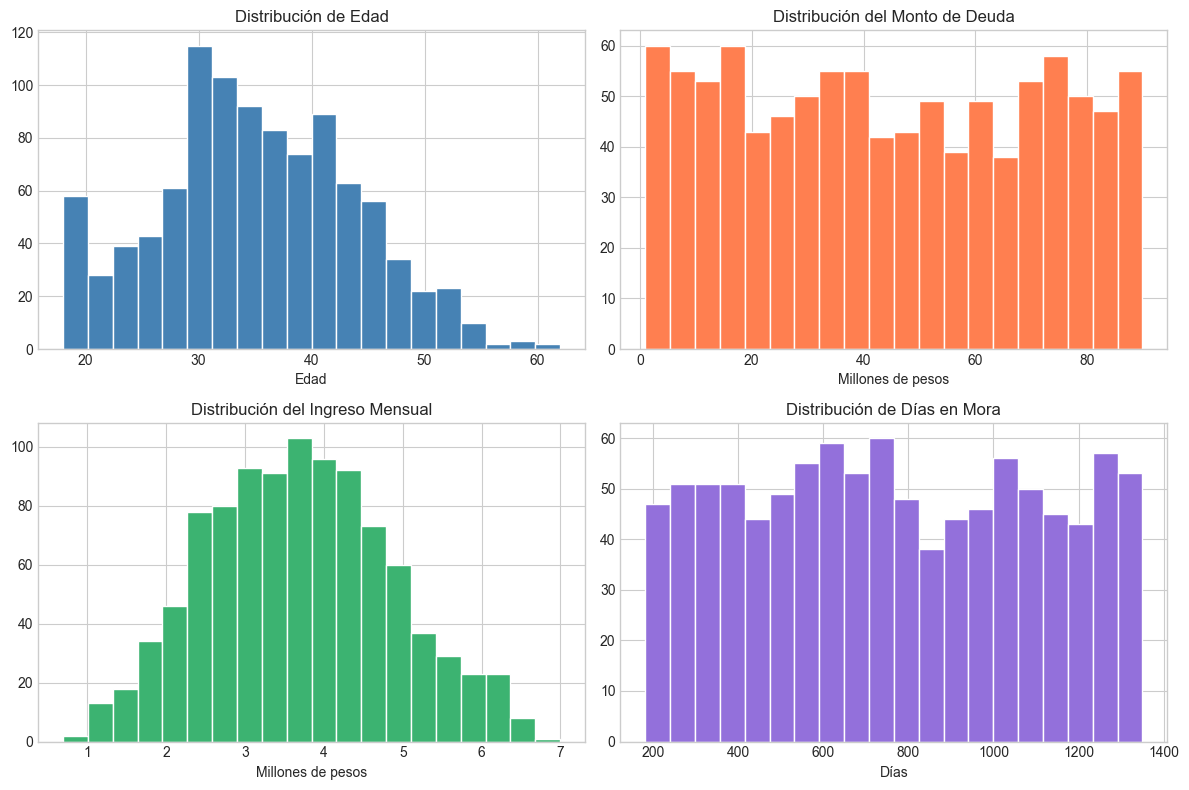

In [8]:
# Histogramas de variables numéricas clave
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(df['edad'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución de Edad')
axes[0,0].set_xlabel('Edad')

axes[0,1].hist(df['monto_deuda']/1000000, bins=20, color='coral', edgecolor='white')
axes[0,1].set_title('Distribución del Monto de Deuda')
axes[0,1].set_xlabel('Millones de pesos')

axes[1,0].hist(df['ingreso']/1000000, bins=20, color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Distribución del Ingreso Mensual')
axes[1,0].set_xlabel('Millones de pesos')

axes[1,1].hist(df['dias_mora'], bins=20, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Distribución de Días en Mora')
axes[1,1].set_xlabel('Días')

plt.tight_layout()
plt.show()

## 2.2 Diagramas de Cajas (Boxplots)

Identificamos valores atípicos y comparamos distribuciones.

C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\484700277.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='resultado', y='edad', ax=axes[0], palette='Set2')
C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\484700277.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='resultado', y='monto_deuda', ax=axes[1], palette='Set2')
C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\484700277.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='resultado', y='ingreso', ax=axes[2], pa

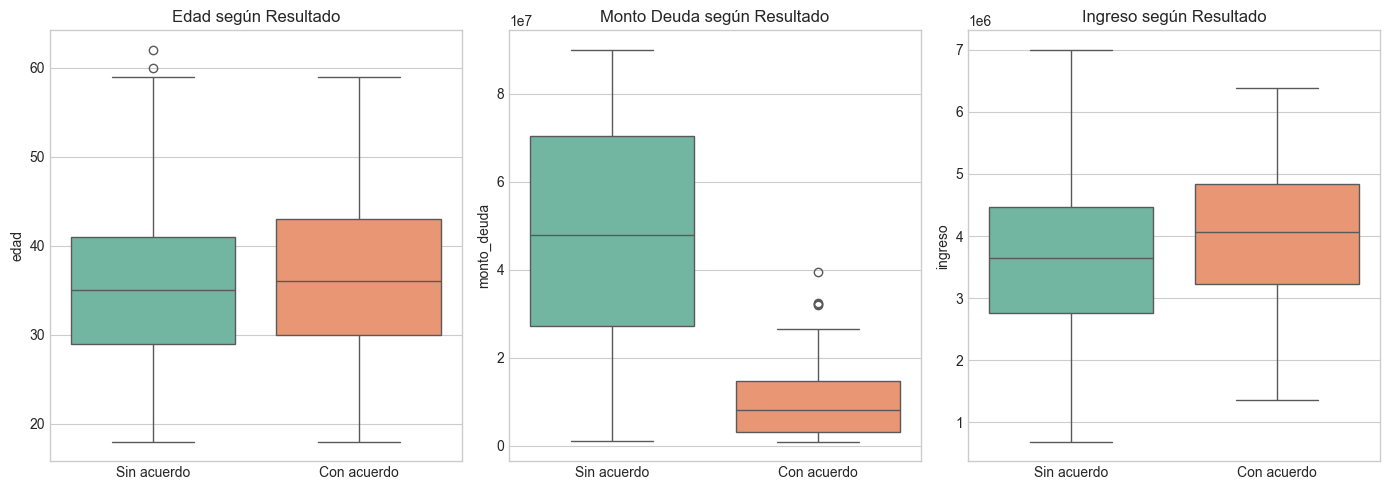

In [9]:
# Boxplots comparando con la variable objetivo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

df['resultado'] = df['acuerdo_logrado'].map({0: 'Sin acuerdo', 1: 'Con acuerdo'})

sns.boxplot(data=df, x='resultado', y='edad', ax=axes[0], palette='Set2')
axes[0].set_title('Edad según Resultado')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='resultado', y='monto_deuda', ax=axes[1], palette='Set2')
axes[1].set_title('Monto Deuda según Resultado')
axes[1].set_xlabel('')

sns.boxplot(data=df, x='resultado', y='ingreso', ax=axes[2], palette='Set2')
axes[2].set_title('Ingreso según Resultado')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

## 2.3 Mapa de Calor (Correlaciones)

Visualizamos las correlaciones entre variables numéricas.

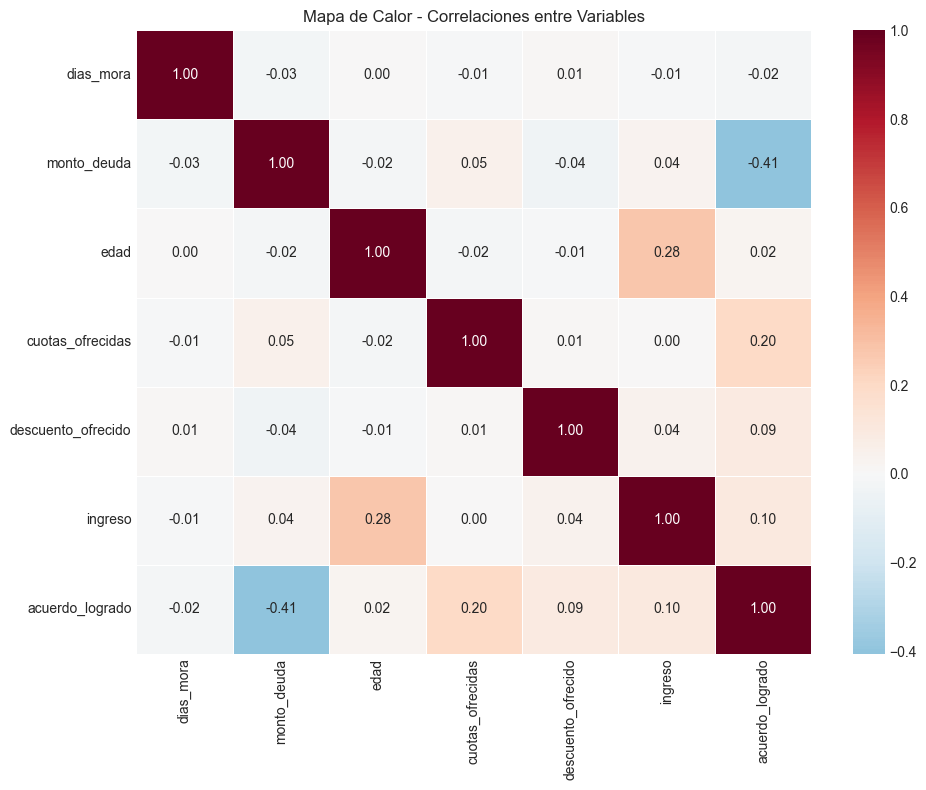

In [10]:
# Mapa de calor de correlaciones
variables_numericas = ['dias_mora', 'monto_deuda', 'edad', 'cuotas_ofrecidas', 
                       'descuento_ofrecido', 'ingreso', 'acuerdo_logrado']

correlaciones = df[variables_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlaciones, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor - Correlaciones entre Variables')
plt.tight_layout()
plt.show()

## 2.4 Diagramas de Dispersión (Scatter Plots)

Exploramos relaciones entre pares de variables.

C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\3271067543.py:10: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  axes[0].legend(*scatter1.legend_elements(), title='Acuerdo', labels=['No', 'Sí'])
C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\3271067543.py:18: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  axes[1].legend(*scatter2.legend_elements(), title='Acuerdo', labels=['No', 'Sí'])


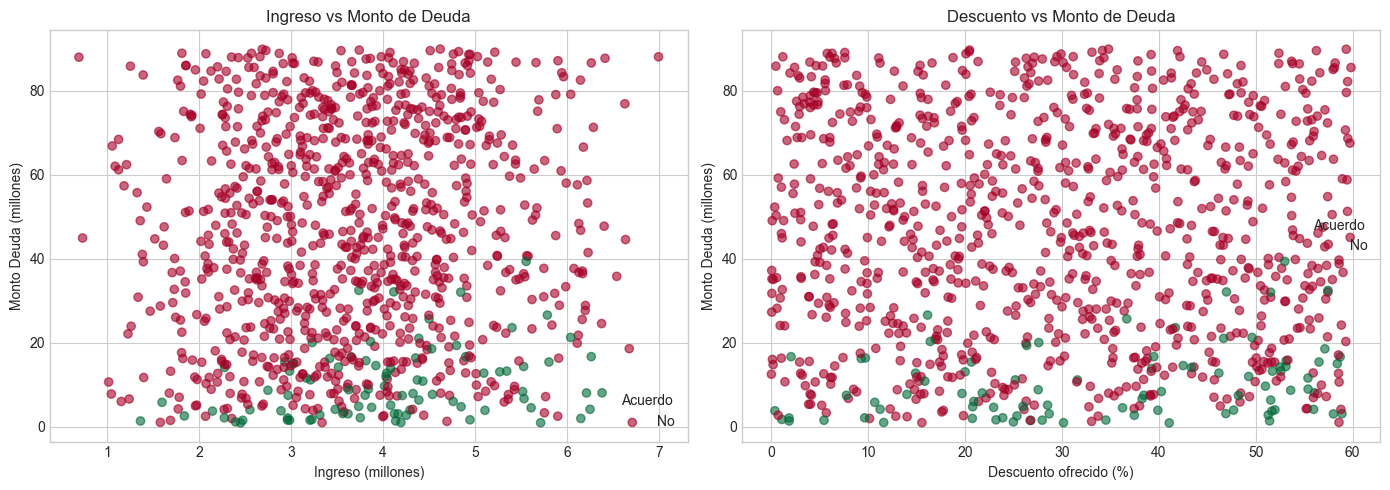

In [11]:
# Diagramas de dispersión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ingreso vs Monto de deuda
scatter1 = axes[0].scatter(df['ingreso']/1000000, df['monto_deuda']/1000000, 
                           c=df['acuerdo_logrado'], cmap='RdYlGn', alpha=0.6)
axes[0].set_xlabel('Ingreso (millones)')
axes[0].set_ylabel('Monto Deuda (millones)')
axes[0].set_title('Ingreso vs Monto de Deuda')
axes[0].legend(*scatter1.legend_elements(), title='Acuerdo', labels=['No', 'Sí'])

# Descuento vs Monto de deuda
scatter2 = axes[1].scatter(df['descuento_ofrecido']*100, df['monto_deuda']/1000000,
                           c=df['acuerdo_logrado'], cmap='RdYlGn', alpha=0.6)
axes[1].set_xlabel('Descuento ofrecido (%)')
axes[1].set_ylabel('Monto Deuda (millones)')
axes[1].set_title('Descuento vs Monto de Deuda')
axes[1].legend(*scatter2.legend_elements(), title='Acuerdo', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

## 2.5 Gráficos de Barras y Conteos

Distribución de variables categóricas.

C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\2621594357.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tipo_acuerdo = df.groupby(['tipo_credito', 'resultado']).size().unstack(fill_value=0)
C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\2621594357.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  estado_acuerdo = df.groupby(['estado_civil', 'resultado']).size().unstack(fill_value=0)
C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\2621594357.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pa

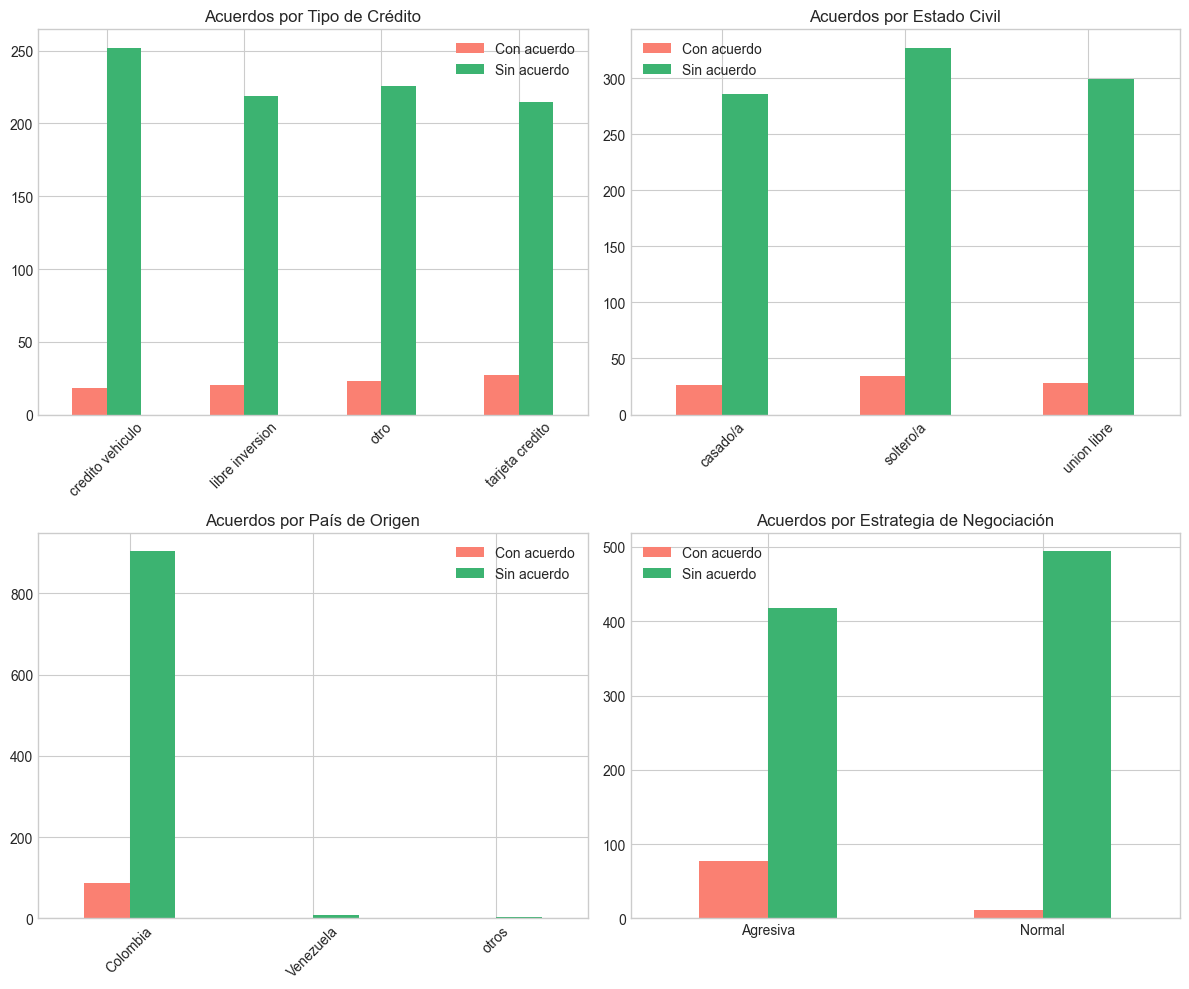

In [12]:
# Gráficos de barras para variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Tipo de crédito
tipo_acuerdo = df.groupby(['tipo_credito', 'resultado']).size().unstack(fill_value=0)
tipo_acuerdo.plot(kind='bar', ax=axes[0,0], color=['salmon', 'mediumseagreen'])
axes[0,0].set_title('Acuerdos por Tipo de Crédito')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(title='')

# Estado civil
estado_acuerdo = df.groupby(['estado_civil', 'resultado']).size().unstack(fill_value=0)
estado_acuerdo.plot(kind='bar', ax=axes[0,1], color=['salmon', 'mediumseagreen'])
axes[0,1].set_title('Acuerdos por Estado Civil')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='')

# País de origen
pais_acuerdo = df.groupby(['pais_origen', 'resultado']).size().unstack(fill_value=0)
pais_acuerdo.plot(kind='bar', ax=axes[1,0], color=['salmon', 'mediumseagreen'])
axes[1,0].set_title('Acuerdos por País de Origen')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(title='')

# Estrategia de negociación
df['estrategia'] = df['negociacion_agresiva'].map({0: 'Normal', 1: 'Agresiva'})
estrategia_acuerdo = df.groupby(['estrategia', 'resultado']).size().unstack(fill_value=0)
estrategia_acuerdo.plot(kind='bar', ax=axes[1,1], color=['salmon', 'mediumseagreen'])
axes[1,1].set_title('Acuerdos por Estrategia de Negociación')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='')

plt.tight_layout()
plt.show()

## 2.6 Gráfico Lineal

Evolución de acuerdos por mes.

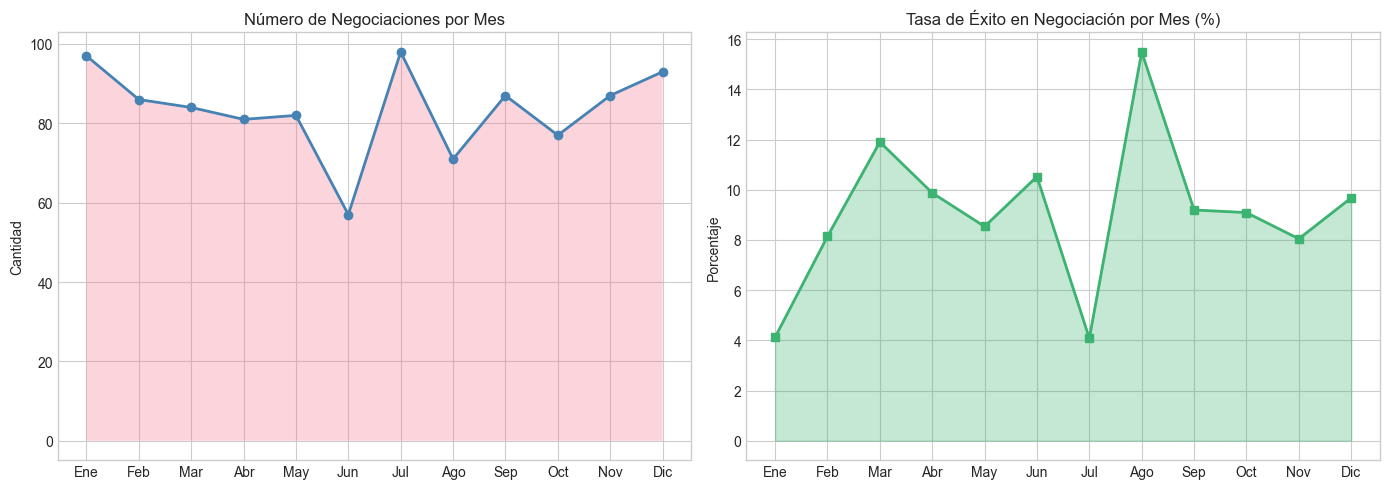

In [13]:
# Gráfico lineal: Tasa de acuerdo por mes
acuerdos_mes = df.groupby('mes').agg({
    'acuerdo_logrado': ['sum', 'count']
}).reset_index()
acuerdos_mes.columns = ['mes', 'acuerdos', 'total']
acuerdos_mes['tasa_acuerdo'] = (acuerdos_mes['acuerdos'] / acuerdos_mes['total']) * 100

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Número de negociaciones por mes
axes[0].plot(acuerdos_mes['mes'], acuerdos_mes['total'], marker='o', linewidth=2, color='steelblue')
axes[0].fill_between(acuerdos_mes['mes'], acuerdos_mes['total'], alpha=0.3)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses)
axes[0].set_title('Número de Negociaciones por Mes')
axes[0].set_ylabel('Cantidad')

# Tasa de éxito por mes
axes[1].plot(acuerdos_mes['mes'], acuerdos_mes['tasa_acuerdo'], marker='s', linewidth=2, color='mediumseagreen')
axes[1].fill_between(acuerdos_mes['mes'], acuerdos_mes['tasa_acuerdo'], alpha=0.3, color='mediumseagreen')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses)
axes[1].set_title('Tasa de Éxito en Negociación por Mes (%)')
axes[1].set_ylabel('Porcentaje')

plt.tight_layout()
plt.show()

## 2.7 Pictograma (Waffle Chart)

Representación visual de proporciones usando iconos.

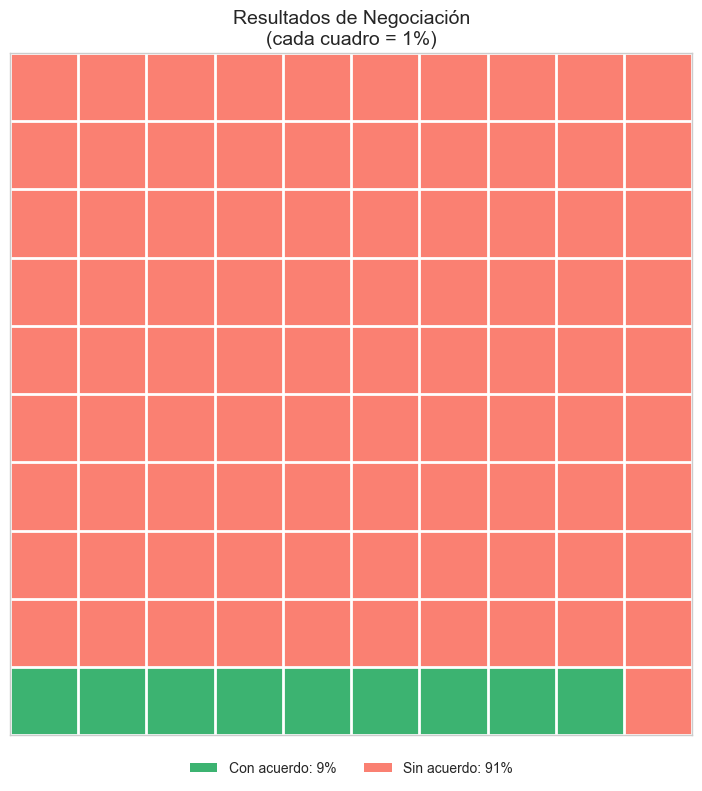


Total de casos: 1000
Con acuerdo: 88 (9%)
Sin acuerdo: 912 (91%)


In [14]:
# Pictograma simple usando matplotlib
# Cada cuadrito representa 1% de los datos

con_acuerdo = df['acuerdo_logrado'].sum()
sin_acuerdo = len(df) - con_acuerdo
pct_acuerdo = round(con_acuerdo / len(df) * 100)
pct_sin = 100 - pct_acuerdo

# Crear matriz 10x10 para el waffle
waffle_data = np.zeros((10, 10))
count = 0
for i in range(10):
    for j in range(10):
        if count < pct_acuerdo:
            waffle_data[9-i, j] = 1  # Con acuerdo
        count += 1

# Visualizar
fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.cm.colors.ListedColormap(['salmon', 'mediumseagreen'])
ax.imshow(waffle_data, cmap=cmap, aspect='equal')

# Añadir grid
for i in range(11):
    ax.axhline(i - 0.5, color='white', linewidth=2)
    ax.axvline(i - 0.5, color='white', linewidth=2)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f'Resultados de Negociación\n(cada cuadro = 1%)', fontsize=14)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='mediumseagreen', label=f'Con acuerdo: {pct_acuerdo}%'),
    Patch(facecolor='salmon', label=f'Sin acuerdo: {pct_sin}%')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2)

plt.tight_layout()
plt.show()

print(f"\nTotal de casos: {len(df)}")
print(f"Con acuerdo: {con_acuerdo} ({pct_acuerdo}%)")
print(f"Sin acuerdo: {sin_acuerdo} ({pct_sin}%)")

## 2.8 Resumen Visual Final

Vista general de las principales características del dataset.

In [15]:
# Resumen estadístico final
print("="*50)
print("RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("="*50)

print("\n📊 VARIABLES NUMÉRICAS:")
print(df[['edad', 'monto_deuda', 'ingreso', 'dias_mora', 'descuento_ofrecido']].describe().round(2))

print("\n\n📋 VARIABLES CATEGÓRICAS:")
print(f"\nTipos de crédito: {df['tipo_credito'].value_counts().to_dict()}")
print(f"\nEstados civiles: {df['estado_civil'].value_counts().to_dict()}")
print(f"\nPaís de origen: {df['pais_origen'].value_counts().to_dict()}")

print("\n\n🎯 VARIABLE OBJETIVO:")
print(f"Tasa de acuerdo: {df['acuerdo_logrado'].mean()*100:.1f}%")

RESUMEN DEL ANÁLISIS EXPLORATORIO

📊 VARIABLES NUMÉRICAS:
          edad  monto_deuda     ingreso  dias_mora  descuento_ofrecido
count  1000.00      1000.00     1000.00    1000.00             1000.00
mean     35.01  44585388.70  3685860.77     764.65                0.29
std       8.73  26403428.98  1183487.57     337.42                0.17
min      18.00    953929.21   690423.61     182.00                0.00
25%      29.00  21238318.86  2807265.02     482.00                0.15
50%      35.00  43756150.65  3667244.45     745.50                0.29
75%      41.00  68354386.27  4495535.95    1054.25                0.44
max      62.00  89899983.05  6996183.26    1350.00                0.60


📋 VARIABLES CATEGÓRICAS:

Tipos de crédito: {'credito vehiculo': 270, 'otro': 249, 'tarjeta credito': 242, 'libre inversion': 239}

Estados civiles: {'soltero/a': 361, 'union libre': 327, 'casado/a': 312}

País de origen: {'Colombia': 990, 'Venezuela': 8, 'otros': 2}


🎯 VARIABLE OBJETIVO:
Tasa de ac

Hasta este punto del EDA, encontramos lo común de un dataset, a continuación describiré un par de hallazgos para ejemplificar que a pesar de que es un dataset sintético tiene un muy buen punto reflectante de la realidad. 

- Lo que podemos observar a priori es que hay una muy baja tasa de acuerdo de pago a los deudores (8.8%)
- Hay 3 diferentes tipos de crédito (Tarjeta, Libre Inversión, crédito vehículo)
- Nuestra distribución de edad tiene un leve sesgo a la derecha lo que indica que personas de mayores años son las que más adeudan 
- Particularmente la distribución de los ingresos es normal, lo que asegura es cierta medida un balance muy coincidencial de ingresos entre distintos grupos étarios. 
- Mayormente los deudores son de Colombia, y no reaccionan a estrategias agresivas de cobranza 
- La tasa de éxito de las negociación por mes es coherente con el promedio establecido y podemos notar que el éxito cae en julio, acá añadimos que coincidencialmente el número de negociaciones por mes cae en junio (un mes antes).

---

# Parte 3: Análisis descriptivo y validación de hipótesis.

En esta sección exploramos relaciones específicas entre variables para validar hipótesis sobre qué factores influyen en el logro de acuerdos de pago.

## 3.1 Relación entre Ingreso y Probabilidad de Acuerdo

**Hipótesis:** Los deudores con mayores ingresos tienen mayor probabilidad de llegar a un acuerdo de pago.

**Método:** Dividimos el ingreso en 5 grupos (quintiles) y calculamos la tasa de acuerdo para cada grupo.

Tasa de acuerdo por quintil de ingreso:
  Q1 (Bajo): 5.0% (n=200)
  Q2: 7.5% (n=200)
  Q3: 8.0% (n=200)
  Q4: 11.0% (n=200)
  Q5 (Alto): 12.5% (n=200)


C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\951657114.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_por_quintil = df.groupby('quintil_ingreso')['acuerdo_logrado'].mean() * 100


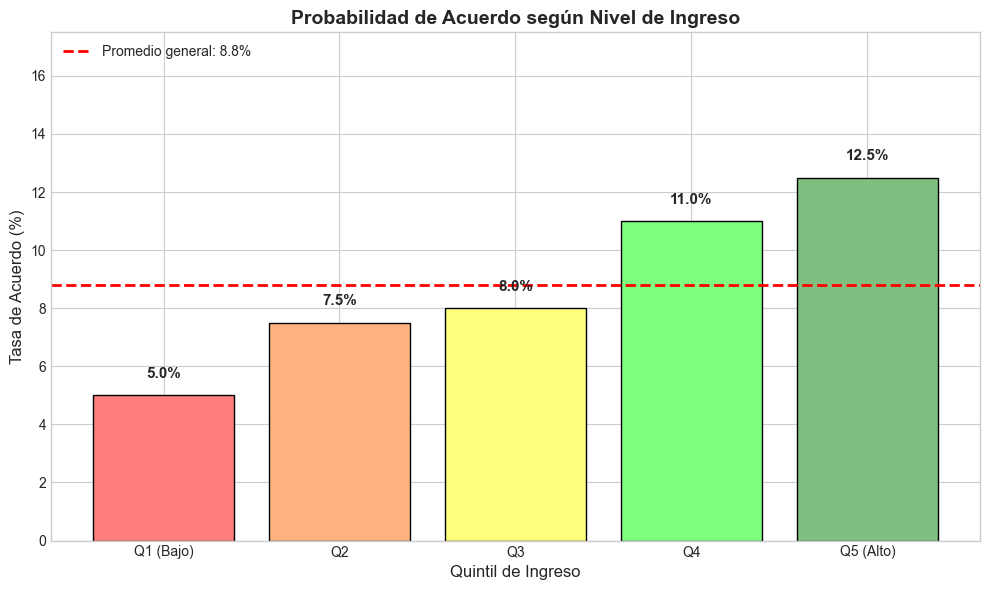


INTERPRETACIÓN:
Los deudores con ingresos altos (Q5) tienen 7.5 puntos
porcentuales más de probabilidad de acuerdo que los de ingresos bajos (Q1).


In [16]:
# Crear quintiles de ingreso
df['quintil_ingreso'] = pd.qcut(df['ingreso'], q=5, labels=['Q1 (Bajo)', 'Q2', 'Q3', 'Q4', 'Q5 (Alto)'])

# Calcular tasa de acuerdo por quintil
tasa_por_quintil = df.groupby('quintil_ingreso')['acuerdo_logrado'].mean() * 100

# Mostrar tabla de resultados
print("Tasa de acuerdo por quintil de ingreso:")
print("="*45)
for quintil, tasa in tasa_por_quintil.items():
    n = df[df['quintil_ingreso'] == quintil].shape[0]
    print(f"  {quintil}: {tasa:.1f}% (n={n})")

# Crear gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))

colores = ['#ff7f7f', '#ffb27f', '#ffff7f', '#7fff7f', '#7fbf7f']
barras = ax.bar(tasa_por_quintil.index, tasa_por_quintil.values, color=colores, edgecolor='black')

# Añadir etiquetas sobre las barras
for barra, valor in zip(barras, tasa_por_quintil.values):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5, 
            f'{valor:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Línea horizontal con el promedio general
promedio_general = df['acuerdo_logrado'].mean() * 100
ax.axhline(y=promedio_general, color='red', linestyle='--', linewidth=2, label=f'Promedio general: {promedio_general:.1f}%')

ax.set_xlabel('Quintil de Ingreso', fontsize=12)
ax.set_ylabel('Tasa de Acuerdo (%)', fontsize=12)
ax.set_title('Probabilidad de Acuerdo según Nivel de Ingreso', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_ylim(0, max(tasa_por_quintil.values) + 5)

plt.tight_layout()
plt.show()

# Interpretación
print("\n" + "="*45)
print("INTERPRETACIÓN:")
print("="*45)
if tasa_por_quintil['Q5 (Alto)'] > tasa_por_quintil['Q1 (Bajo)']:
    diferencia = tasa_por_quintil['Q5 (Alto)'] - tasa_por_quintil['Q1 (Bajo)']
    print(f"Los deudores con ingresos altos (Q5) tienen {diferencia:.1f} puntos")
    print("porcentuales más de probabilidad de acuerdo que los de ingresos bajos (Q1).")
else:
    print("No se observa una relación clara entre ingreso y probabilidad de acuerdo.")

## 3.2 Esfuerzo de Pago (Ratio Pago) y su Relación con el Acuerdo

**Hipótesis:** Los deudores que llegan a un acuerdo enfrentan, en promedio, un menor esfuerzo de pago relativo.

**Método:** 
1. Creamos una variable `cuota_implicita` = monto_deuda × (1 - descuento_ofrecido) / cuotas_propuestas
2. Calculamos el `ratio_pago` = cuota_implicita / ingreso (proxy de esfuerzo de pago)
3. Eliminamos valores extremos (percentil 99) para evitar distorsiones
4. Comparamos la distribución del ratio entre quienes lograron acuerdo vs quienes no

*Nota: Este es un análisis descriptivo sin controles. No implica causalidad.*

CONSTRUCCIÓN DEL PROXY DE ESFUERZO DE PAGO

Fórmula: cuota_implicita = monto_deuda × (1 - descuento) / cuotas
         ratio_pago = cuota_implicita / ingreso

Observaciones originales: 1000
Percentil 99 del ratio_pago: 18.3770
Observaciones después de eliminar extremos: 990
Observaciones eliminadas: 10

ESTADÍSTICAS DEL RATIO DE PAGO POR GRUPO

SIN acuerdo (n=902):
  Media:    2.4190
  Mediana:  1.4222
  Desv.Est: 2.7669
  Min-Max:  0.0236 - 18.3741

CON acuerdo (n=88):
  Media:    0.1849
  Mediana:  0.1765
  Desv.Est: 0.1226
  Min-Max:  0.0121 - 0.5227


C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\421314789.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([datos_sin, datos_con], labels=['Sin Acuerdo', 'Con Acuerdo'],


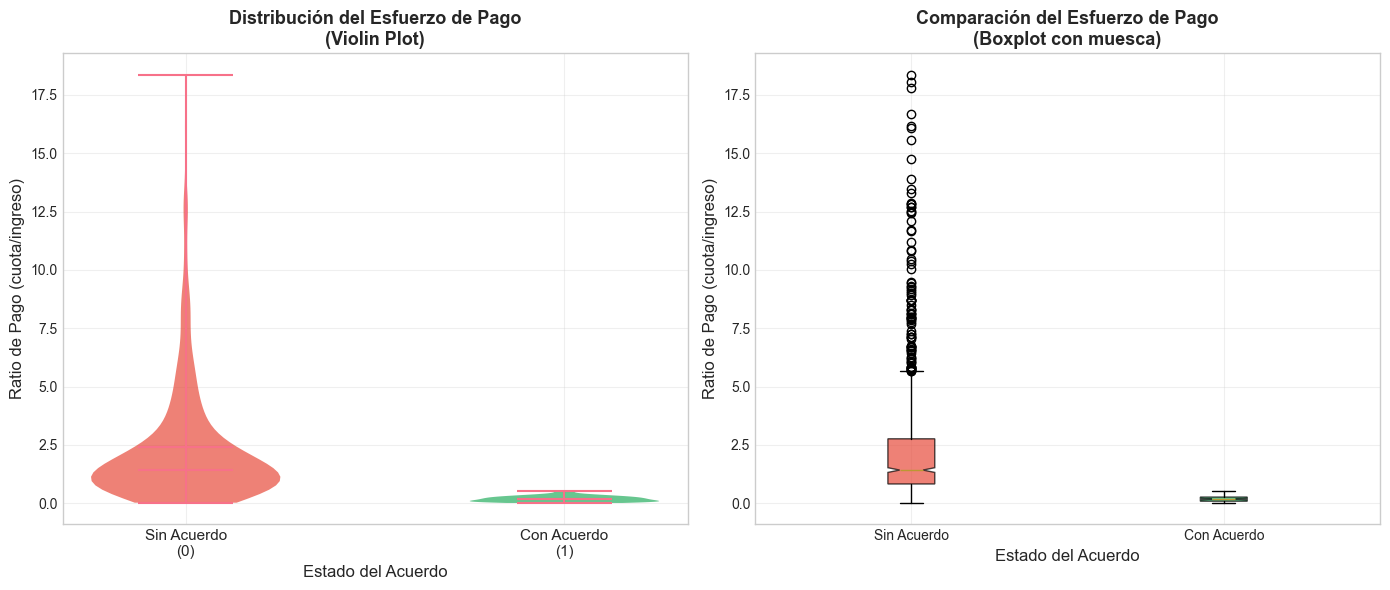


INTERPRETACIÓN
✓ Los deudores CON acuerdo tienen un ratio de pago promedio MENOR
  que quienes no llegaron a acuerdo.

Media ratio_pago SIN acuerdo: 2.4190
Media ratio_pago CON acuerdo: 0.1849
Diferencia absoluta: 2.2341
Diferencia relativa: 92.4%


In [17]:
# 1. Crear la variable cuota_implicita
# cuota_implicita = deuda * (1 - descuento) / cuotas
df['cuota_implicita'] = df['monto_deuda'] * (1 - df['descuento_ofrecido']) / df['cuotas_ofrecidas']

# 2. Crear la variable ratio_pago (proxy de esfuerzo de pago)
# ratio_pago = cuota_implicita / ingreso
df['ratio_pago'] = df['cuota_implicita'] / df['ingreso']

# 3. Eliminar valores extremos (percentil 99) para evitar distorsiones
percentil_99 = df['ratio_pago'].quantile(0.99)
df_analisis = df[df['ratio_pago'] <= percentil_99].copy()

print("="*60)
print("CONSTRUCCIÓN DEL PROXY DE ESFUERZO DE PAGO")
print("="*60)
print(f"\nFórmula: cuota_implicita = monto_deuda × (1 - descuento) / cuotas")
print(f"         ratio_pago = cuota_implicita / ingreso")
print(f"\nObservaciones originales: {len(df)}")
print(f"Percentil 99 del ratio_pago: {percentil_99:.4f}")
print(f"Observaciones después de eliminar extremos: {len(df_analisis)}")
print(f"Observaciones eliminadas: {len(df) - len(df_analisis)}")

# 4. Estadísticas descriptivas por grupo
print("\n" + "="*60)
print("ESTADÍSTICAS DEL RATIO DE PAGO POR GRUPO")
print("="*60)

for grupo in [0, 1]:
    datos = df_analisis[df_analisis['acuerdo_logrado'] == grupo]['ratio_pago']
    etiqueta = "CON acuerdo" if grupo == 1 else "SIN acuerdo"
    print(f"\n{etiqueta} (n={len(datos)}):")
    print(f"  Media:    {datos.mean():.4f}")
    print(f"  Mediana:  {datos.median():.4f}")
    print(f"  Desv.Est: {datos.std():.4f}")
    print(f"  Min-Max:  {datos.min():.4f} - {datos.max():.4f}")

# 5. Crear violin plot para comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin plot
ax1 = axes[0]
datos_sin = df_analisis[df_analisis['acuerdo_logrado'] == 0]['ratio_pago']
datos_con = df_analisis[df_analisis['acuerdo_logrado'] == 1]['ratio_pago']

parts = ax1.violinplot([datos_sin, datos_con], positions=[0, 1], showmeans=True, showmedians=True)

# Personalizar colores
parts['bodies'][0].set_facecolor('#E74C3C')
parts['bodies'][0].set_alpha(0.7)
parts['bodies'][1].set_facecolor('#27AE60')
parts['bodies'][1].set_alpha(0.7)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Sin Acuerdo\n(0)', 'Con Acuerdo\n(1)'], fontsize=11)
ax1.set_xlabel('Estado del Acuerdo', fontsize=12)
ax1.set_ylabel('Ratio de Pago (cuota/ingreso)', fontsize=12)
ax1.set_title('Distribución del Esfuerzo de Pago\n(Violin Plot)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Boxplot para comparación
ax2 = axes[1]
colores_box = ['#E74C3C', '#27AE60']
bp = ax2.boxplot([datos_sin, datos_con], labels=['Sin Acuerdo', 'Con Acuerdo'], 
                  patch_artist=True, notch=True)

for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Estado del Acuerdo', fontsize=12)
ax2.set_ylabel('Ratio de Pago (cuota/ingreso)', fontsize=12)
ax2.set_title('Comparación del Esfuerzo de Pago\n(Boxplot con muesca)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación
print("\n" + "="*60)
print("INTERPRETACIÓN")
print("="*60)
media_sin = datos_sin.mean()
media_con = datos_con.mean()
diferencia = media_sin - media_con
diferencia_pct = (diferencia / media_sin) * 100

if media_con < media_sin:
    print(f"✓ Los deudores CON acuerdo tienen un ratio de pago promedio MENOR")
    print(f"  que quienes no llegaron a acuerdo.")
else:
    print(f"✗ Los deudores CON acuerdo tienen un ratio de pago promedio MAYOR")
    print(f"  que quienes no llegaron a acuerdo.")

print(f"\nMedia ratio_pago SIN acuerdo: {media_sin:.4f}")
print(f"Media ratio_pago CON acuerdo: {media_con:.4f}")
print(f"Diferencia absoluta: {abs(diferencia):.4f}")
print(f"Diferencia relativa: {abs(diferencia_pct):.1f}%")

## 3.3 Relación entre Descuento Ofrecido y Probabilidad de Acuerdo

**Hipótesis:** A mayor descuento ofrecido, mayor probabilidad de que el deudor acepte un acuerdo.

**Método:** Dividimos el descuento en 10 rangos (deciles) y calculamos la tasa de acuerdo para cada grupo.

*Nota: Este es un análisis descriptivo sin controles. No implica causalidad.*

Tasa de acuerdo por decil de descuento:
  0-10%: 6.0% (n=100)
  10-20%: 6.0% (n=100)
  20-30%: 6.0% (n=100)
  30-40%: 7.0% (n=100)
  40-50%: 14.0% (n=100)
  50-60%: 3.0% (n=100)
  60-70%: 9.0% (n=100)
  70-80%: 8.0% (n=100)
  80-90%: 18.0% (n=100)
  90-100%: 11.0% (n=100)


C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\1562726911.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_por_decil = df.groupby('decil_descuento')['acuerdo_logrado'].mean() * 100


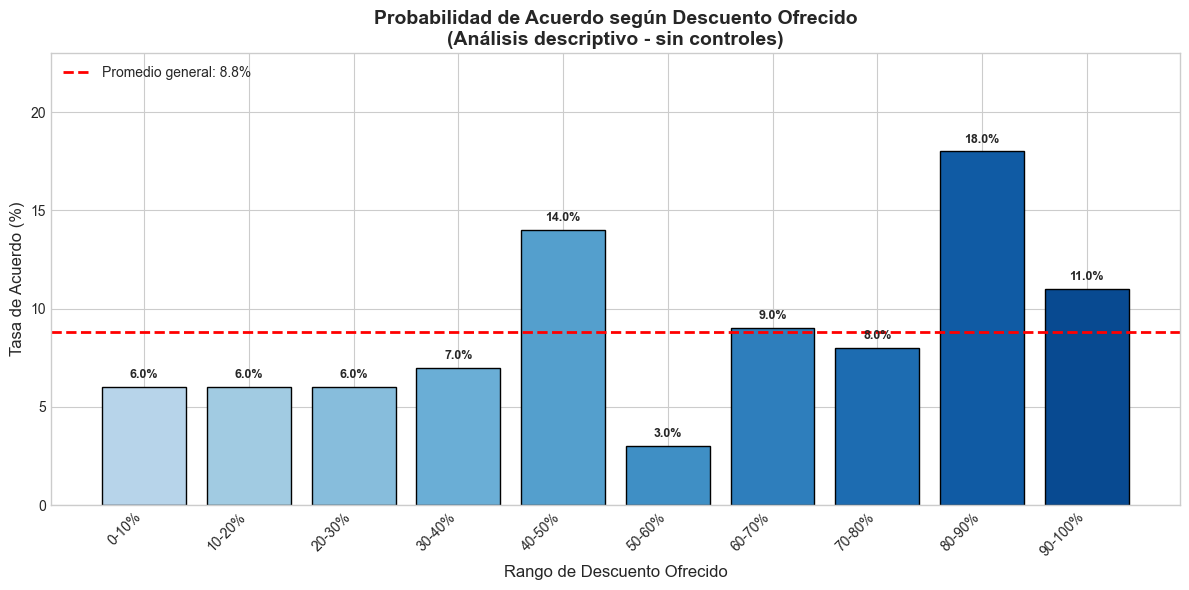


INTERPRETACIÓN:
Mayor tasa de acuerdo: 18.0% en el rango 80-90%
Menor tasa de acuerdo: 3.0% en el rango 50-60%
Diferencia: 15.0 puntos porcentuales


In [18]:
# Crear deciles de descuento ofrecido
df['decil_descuento'] = pd.qcut(df['descuento_ofrecido'], q=10, labels=[
    '0-10%', '10-20%', '20-30%', '30-40%', '40-50%', 
    '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'
])

# Calcular tasa de acuerdo por decil
tasa_por_decil = df.groupby('decil_descuento')['acuerdo_logrado'].mean() * 100

# Mostrar tabla de resultados
print("Tasa de acuerdo por decil de descuento:")
print("="*50)
for decil, tasa in tasa_por_decil.items():
    n = df[df['decil_descuento'] == decil].shape[0]
    print(f"  {decil}: {tasa:.1f}% (n={n})")

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Colores en gradiente de azul
colores = plt.cm.Blues(np.linspace(0.3, 0.9, 10))
barras = ax.bar(range(len(tasa_por_decil)), tasa_por_decil.values, color=colores, edgecolor='black')

# Etiquetas sobre las barras
for i, (barra, valor) in enumerate(zip(barras, tasa_por_decil.values)):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3, 
            f'{valor:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Línea de promedio general
promedio = df['acuerdo_logrado'].mean() * 100
ax.axhline(y=promedio, color='red', linestyle='--', linewidth=2, 
           label=f'Promedio general: {promedio:.1f}%')

ax.set_xticks(range(len(tasa_por_decil)))
ax.set_xticklabels(tasa_por_decil.index, rotation=45, ha='right')
ax.set_xlabel('Rango de Descuento Ofrecido', fontsize=12)
ax.set_ylabel('Tasa de Acuerdo (%)', fontsize=12)
ax.set_title('Probabilidad de Acuerdo según Descuento Ofrecido\n(Análisis descriptivo - sin controles)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_ylim(0, max(tasa_por_decil.values) + 5)

plt.tight_layout()
plt.show()

# Interpretación
print("\n" + "="*50)
print("INTERPRETACIÓN:")
print("="*50)
max_tasa = tasa_por_decil.max()
min_tasa = tasa_por_decil.min()
max_decil = tasa_por_decil.idxmax()
min_decil = tasa_por_decil.idxmin()
print(f"Mayor tasa de acuerdo: {max_tasa:.1f}% en el rango {max_decil}")
print(f"Menor tasa de acuerdo: {min_tasa:.1f}% en el rango {min_decil}")
print(f"Diferencia: {max_tasa - min_tasa:.1f} puntos porcentuales")

## 3.4 Interacción entre Descuento y Antigüedad de la Deuda

**Hipótesis:** El efecto del descuento ofrecido sobre la probabilidad de acuerdo varía según la antigüedad de la deuda.

**Método:** 
1. Dividimos la antigüedad de la deuda (días de mora) en terciles: baja, media y alta antigüedad
2. Dentro de cada grupo, dividimos el descuento en bins y calculamos la tasa de acuerdo
3. Comparamos las curvas de respuesta al descuento entre los tres niveles de antigüedad

*Nota: Este análisis busca visualizar posibles interacciones entre variables. No implica causalidad.*

DISTRIBUCIÓN DE GRUPOS DE ANTIGÜEDAD

Baja (181-365 días): n=334
  Rango días mora: 182 - 578

Media (366-547 días): n=332
  Rango días mora: 580 - 958

Alta (548+ días): n=334
  Rango días mora: 961 - 1350

TASA DE ACUERDO POR ANTIGÜEDAD Y DESCUENTO
                                     Tasa Acuerdo (%)   N
grupo_antiguedad      bin_descuento                      
Baja\n(181-365 días)  0-20%                  8.333333  72
                      20-40%                 9.230769  65
                      40-60%                 5.000000  60
                      60-80%                 8.823529  68
                      80-100%               15.942029  69
Media\n(366-547 días) 0-20%                  3.333333  60
                      20-40%                 4.477612  67
                      40-60%                11.688312  77
                      60-80%                 9.677419  62
                      80-100%               13.636364  66
Alta\n(548+ días)     0-20%                  5.882353

C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\1851203780.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_interaccion = df.groupby(['grupo_antiguedad', 'bin_descuento'])['acuerdo_logrado'].agg(['mean', 'count'])
C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\1851203780.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasas = df_grupo.groupby('bin_descuento')['acuerdo_logrado'].mean() * 100
C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\1851203780.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

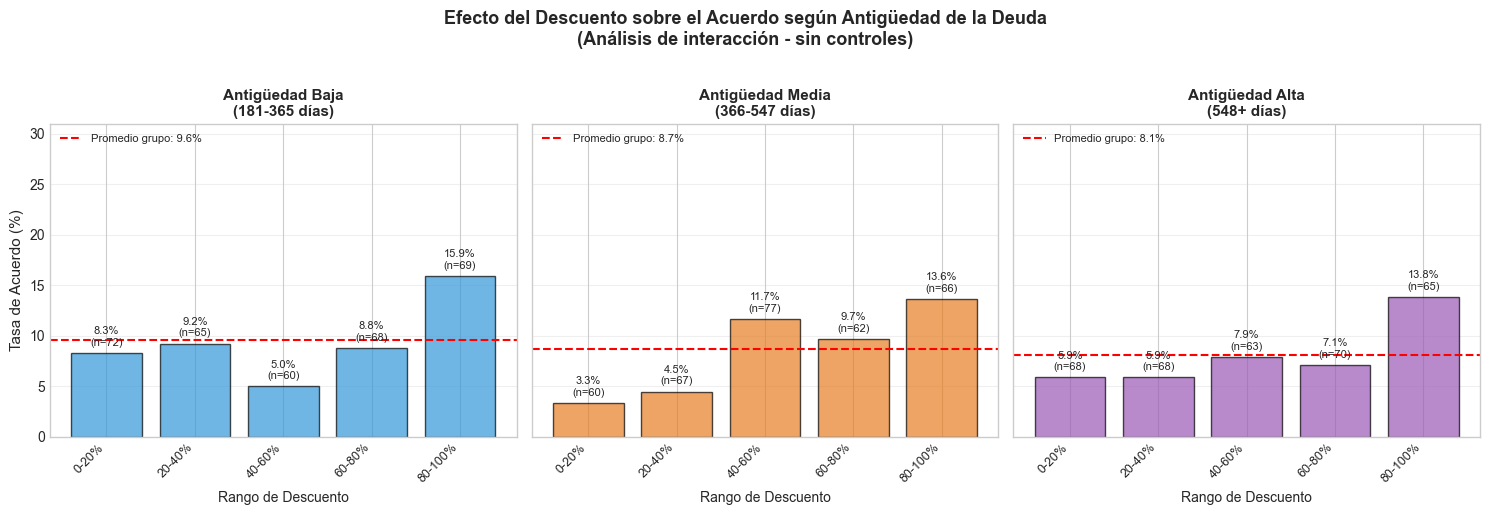

C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\1851203780.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasas = df_grupo.groupby('bin_descuento')['acuerdo_logrado'].mean() * 100


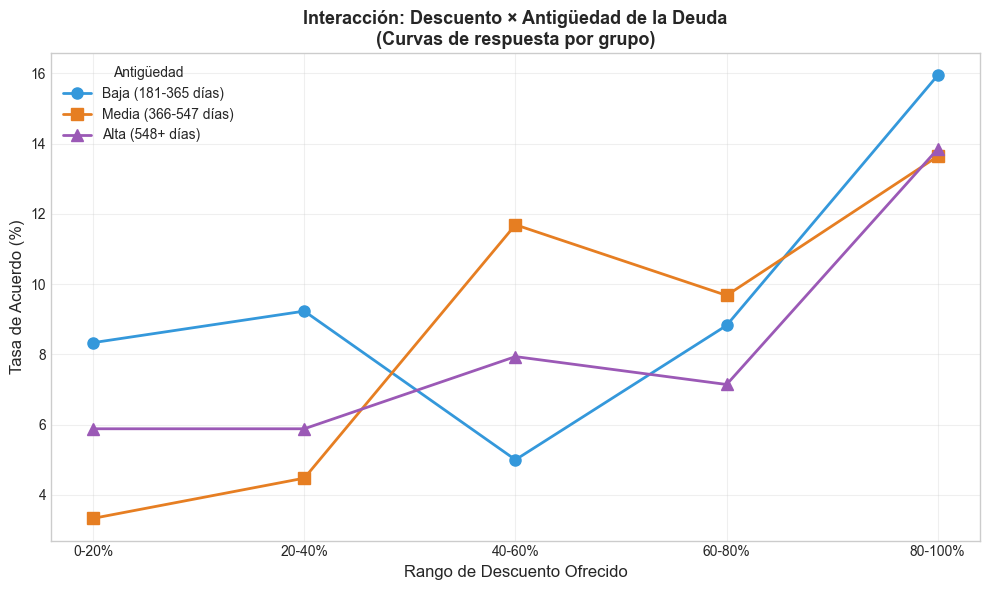


INTERPRETACIÓN
Tasa promedio Baja (181-365 días): 9.6%
Tasa promedio Media (366-547 días): 8.7%
Tasa promedio Alta (548+ días): 8.1%

Observaciones:
- Si las curvas son paralelas: el efecto del descuento es similar en todos los grupos
- Si las curvas divergen/convergen: hay interacción entre descuento y antigüedad
- Pendientes diferentes sugieren que el descuento tiene distinto impacto según antigüedad


In [19]:
# 1. Crear grupos de antigüedad de la deuda (terciles)
df['grupo_antiguedad'] = pd.qcut(df['dias_mora'], q=3, labels=['Baja\n(181-365 días)', 'Media\n(366-547 días)', 'Alta\n(548+ días)'])

# Verificar distribución de grupos
print("="*60)
print("DISTRIBUCIÓN DE GRUPOS DE ANTIGÜEDAD")
print("="*60)
for grupo in df['grupo_antiguedad'].cat.categories:
    datos = df[df['grupo_antiguedad'] == grupo]['dias_mora']
    n = len(datos)
    print(f"\n{grupo.replace(chr(10), ' ')}: n={n}")
    print(f"  Rango días mora: {datos.min():.0f} - {datos.max():.0f}")

# 2. Crear bins de descuento (quintiles)
df['bin_descuento'] = pd.qcut(df['descuento_ofrecido'], q=5, labels=[
    '0-20%', '20-40%', '40-60%', '60-80%', '80-100%'
])

# 3. Calcular tasa de acuerdo por cada combinación
print("\n" + "="*60)
print("TASA DE ACUERDO POR ANTIGÜEDAD Y DESCUENTO")
print("="*60)

# Crear tabla cruzada
tabla_interaccion = df.groupby(['grupo_antiguedad', 'bin_descuento'])['acuerdo_logrado'].agg(['mean', 'count'])
tabla_interaccion['mean'] = tabla_interaccion['mean'] * 100
tabla_interaccion.columns = ['Tasa Acuerdo (%)', 'N']
print(tabla_interaccion.to_string())

# 4. Preparar datos para el gráfico
grupos_antiguedad = df['grupo_antiguedad'].cat.categories
bins_descuento = df['bin_descuento'].cat.categories
colores_antiguedad = ['#3498DB', '#E67E22', '#9B59B6']

# 5. Crear gráfico facetado
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, (grupo, color) in enumerate(zip(grupos_antiguedad, colores_antiguedad)):
    ax = axes[i]
    df_grupo = df[df['grupo_antiguedad'] == grupo]
    
    # Calcular tasa de acuerdo por bin de descuento
    tasas = df_grupo.groupby('bin_descuento')['acuerdo_logrado'].mean() * 100
    conteos = df_grupo.groupby('bin_descuento')['acuerdo_logrado'].count()
    
    # Gráfico de barras
    barras = ax.bar(range(len(tasas)), tasas.values, color=color, edgecolor='black', alpha=0.7)
    
    # Etiquetas sobre las barras
    for j, (barra, tasa, n) in enumerate(zip(barras, tasas.values, conteos.values)):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
                f'{tasa:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=8)
    
    # Línea de promedio del grupo
    promedio_grupo = df_grupo['acuerdo_logrado'].mean() * 100
    ax.axhline(y=promedio_grupo, color='red', linestyle='--', linewidth=1.5,
               label=f'Promedio grupo: {promedio_grupo:.1f}%')
    
    ax.set_xticks(range(len(bins_descuento)))
    ax.set_xticklabels(bins_descuento, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Rango de Descuento', fontsize=10)
    ax.set_title(f'Antigüedad {grupo}', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_ylabel('Tasa de Acuerdo (%)', fontsize=11)

# Establecer misma escala en todos los paneles
max_tasa = df.groupby(['grupo_antiguedad', 'bin_descuento'])['acuerdo_logrado'].mean().max() * 100
for ax in axes:
    ax.set_ylim(0, max_tasa + 15)

plt.suptitle('Efecto del Descuento sobre el Acuerdo según Antigüedad de la Deuda\n(Análisis de interacción - sin controles)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6. Gráfico de líneas para mejor visualización de la interacción
fig, ax = plt.subplots(figsize=(10, 6))

for grupo, color, marker in zip(grupos_antiguedad, colores_antiguedad, ['o', 's', '^']):
    df_grupo = df[df['grupo_antiguedad'] == grupo]
    tasas = df_grupo.groupby('bin_descuento')['acuerdo_logrado'].mean() * 100
    
    ax.plot(range(len(tasas)), tasas.values, marker=marker, markersize=8, 
            linewidth=2, color=color, label=f'{grupo.replace(chr(10), " ")}')

ax.set_xticks(range(len(bins_descuento)))
ax.set_xticklabels(bins_descuento, fontsize=10)
ax.set_xlabel('Rango de Descuento Ofrecido', fontsize=12)
ax.set_ylabel('Tasa de Acuerdo (%)', fontsize=12)
ax.set_title('Interacción: Descuento × Antigüedad de la Deuda\n(Curvas de respuesta por grupo)', 
             fontsize=13, fontweight='bold')
ax.legend(title='Antigüedad', loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. Interpretación
print("\n" + "="*60)
print("INTERPRETACIÓN")
print("="*60)

# Calcular promedios por grupo
for grupo in grupos_antiguedad:
    df_grupo = df[df['grupo_antiguedad'] == grupo]
    promedio = df_grupo['acuerdo_logrado'].mean() * 100
    print(f"Tasa promedio {grupo.replace(chr(10), ' ')}: {promedio:.1f}%")

print("\nObservaciones:")
print("- Si las curvas son paralelas: el efecto del descuento es similar en todos los grupos")
print("- Si las curvas divergen/convergen: hay interacción entre descuento y antigüedad")
print("- Pendientes diferentes sugieren que el descuento tiene distinto impacto según antigüedad")

## 3.5 Comparación de Tasa de Acuerdo por Tipo de Estrategia de Negociación

**Hipótesis:** La estrategia de negociación agresiva podría tener un efecto sobre la probabilidad de acuerdo.

**Método:** Comparación simple de tasas de acuerdo entre estrategia agresiva (1) y no agresiva (0).

*Nota: Este es un análisis exploratorio sin controlar por características del deudor. No implica causalidad.*

TASA DE ACUERDO POR TIPO DE ESTRATEGIA

Estrategia NO agresiva (0):
  Observaciones: 505
  Acuerdos logrados: 11
  Tasa de acuerdo: 2.2%

Estrategia AGRESIVA (1):
  Observaciones: 495
  Acuerdos logrados: 77
  Tasa de acuerdo: 15.6%


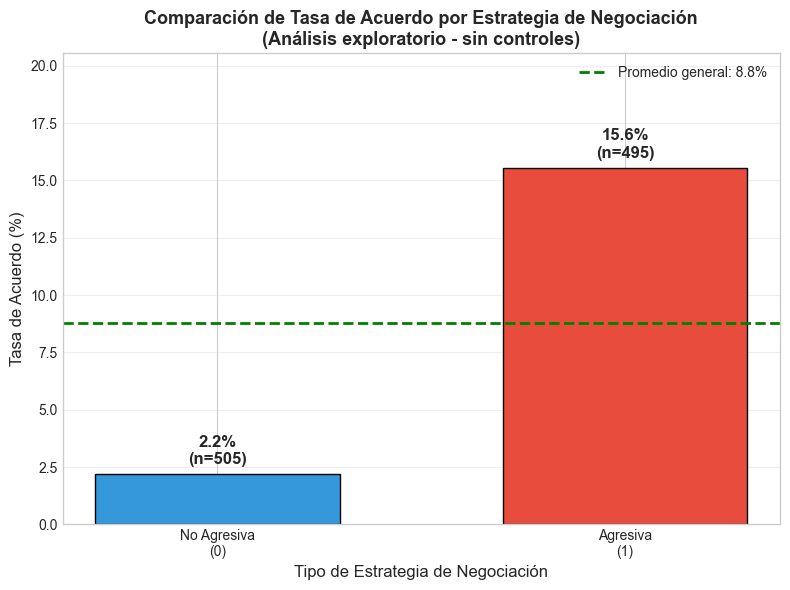


INTERPRETACIÓN
La estrategia AGRESIVA tiene una tasa de acuerdo 13.4 pp MAYOR

Diferencia absoluta: 13.4 puntos porcentuales
Diferencia relativa: 614.1%

⚠️ ADVERTENCIA: Esta comparación NO controla por características
   del deudor. La diferencia podría deberse a confusores.


In [20]:
# 1. Calcular la tasa de acuerdo por tipo de estrategia
tasa_por_estrategia = df.groupby('negociacion_agresiva')['acuerdo_logrado'].agg(['mean', 'sum', 'count'])
tasa_por_estrategia.columns = ['Tasa Acuerdo', 'Total Acuerdos', 'N']
tasa_por_estrategia['Tasa Acuerdo (%)'] = tasa_por_estrategia['Tasa Acuerdo'] * 100

print("="*60)
print("TASA DE ACUERDO POR TIPO DE ESTRATEGIA")
print("="*60)
print(f"\nEstrategia NO agresiva (0):")
print(f"  Observaciones: {tasa_por_estrategia.loc[0, 'N']}")
print(f"  Acuerdos logrados: {tasa_por_estrategia.loc[0, 'Total Acuerdos']:.0f}")
print(f"  Tasa de acuerdo: {tasa_por_estrategia.loc[0, 'Tasa Acuerdo (%)']:.1f}%")

print(f"\nEstrategia AGRESIVA (1):")
print(f"  Observaciones: {tasa_por_estrategia.loc[1, 'N']}")
print(f"  Acuerdos logrados: {tasa_por_estrategia.loc[1, 'Total Acuerdos']:.0f}")
print(f"  Tasa de acuerdo: {tasa_por_estrategia.loc[1, 'Tasa Acuerdo (%)']:.1f}%")

# 2. Crear gráfico de barras
fig, ax = plt.subplots(figsize=(8, 6))

# Datos para el gráfico
estrategias = ['No Agresiva\n(0)', 'Agresiva\n(1)']
tasas = [tasa_por_estrategia.loc[0, 'Tasa Acuerdo (%)'], 
         tasa_por_estrategia.loc[1, 'Tasa Acuerdo (%)']]
n_obs = [tasa_por_estrategia.loc[0, 'N'], 
         tasa_por_estrategia.loc[1, 'N']]
colores = ['#3498DB', '#E74C3C']

# Gráfico de barras
barras = ax.bar(estrategias, tasas, color=colores, edgecolor='black', width=0.6)

# Etiquetas sobre las barras
for barra, tasa, n in zip(barras, tasas, n_obs):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
            f'{tasa:.1f}%\n(n={n:.0f})', ha='center', va='bottom', 
            fontsize=12, fontweight='bold')

# Línea de promedio general
promedio_general = df['acuerdo_logrado'].mean() * 100
ax.axhline(y=promedio_general, color='green', linestyle='--', linewidth=2,
           label=f'Promedio general: {promedio_general:.1f}%')

ax.set_xlabel('Tipo de Estrategia de Negociación', fontsize=12)
ax.set_ylabel('Tasa de Acuerdo (%)', fontsize=12)
ax.set_title('Comparación de Tasa de Acuerdo por Estrategia de Negociación\n(Análisis exploratorio - sin controles)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, max(tasas) + 5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 3. Interpretación
print("\n" + "="*60)
print("INTERPRETACIÓN")
print("="*60)
diferencia = tasas[1] - tasas[0]
diferencia_relativa = (diferencia / tasas[0]) * 100 if tasas[0] > 0 else 0

if diferencia > 0:
    print(f"La estrategia AGRESIVA tiene una tasa de acuerdo {abs(diferencia):.1f} pp MAYOR")
elif diferencia < 0:
    print(f"La estrategia AGRESIVA tiene una tasa de acuerdo {abs(diferencia):.1f} pp MENOR")
else:
    print("Ambas estrategias tienen la misma tasa de acuerdo")

print(f"\nDiferencia absoluta: {diferencia:.1f} puntos porcentuales")
print(f"Diferencia relativa: {abs(diferencia_relativa):.1f}%")
print("\n⚠️ ADVERTENCIA: Esta comparación NO controla por características")
print("   del deudor. La diferencia podría deberse a confusores.")

## 3.6 Efecto Heterogéneo de la Estrategia Agresiva según Nivel de Ingreso

**Hipótesis:** El efecto de la estrategia de negociación agresiva sobre el acuerdo podría variar según el nivel de ingreso del deudor.

**Método:** 
1. Dividimos el ingreso en terciles: bajo, medio y alto
2. Para cada grupo de ingreso, calculamos la tasa de acuerdo separando por tipo de estrategia
3. Visualizamos mediante gráfico de barras agrupadas

*Nota: Este es un análisis exploratorio para detectar efectos heterogéneos. No implica causalidad.*

DISTRIBUCIÓN DE GRUPOS DE INGRESO

Bajo: n=334
  Rango ingreso: $690,424 - $3,104,449

Medio: n=333
  Rango ingreso: $3,109,286 - $4,195,189

Alto: n=333
  Rango ingreso: $4,198,052 - $6,996,183

TASA DE ACUERDO POR INGRESO Y ESTRATEGIA
                                    Tasa Acuerdo (%)    N
grupo_ingreso negociacion_agresiva                       
Bajo          0                             3.164557  158
              1                             7.954545  176
Medio         0                             1.724138  174
              1                            18.238994  159
Alto          0                             1.734104  173
              1                            21.250000  160


C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\47502444.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_heterogenea = df.groupby(['grupo_ingreso', 'negociacion_agresiva'])['acuerdo_logrado'].agg(['mean', 'count'])


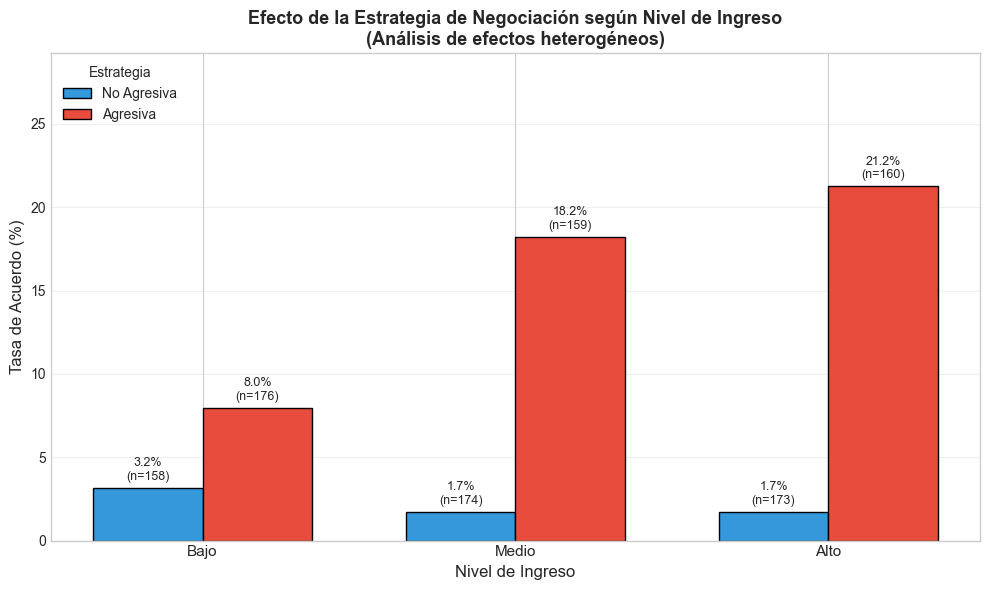


EFECTO DE LA ESTRATEGIA AGRESIVA POR GRUPO DE INGRESO

Bajo:
  No Agresiva: 3.2% (n=158)
  Agresiva: 8.0% (n=176)
  Diferencia: +4.8 pp

Medio:
  No Agresiva: 1.7% (n=174)
  Agresiva: 18.2% (n=159)
  Diferencia: +16.5 pp

Alto:
  No Agresiva: 1.7% (n=173)
  Agresiva: 21.2% (n=160)
  Diferencia: +19.5 pp

INTERPRETACIÓN
Mayor efecto de la estrategia agresiva: en ingresos Alto (+19.5 pp)
Menor efecto de la estrategia agresiva: en ingresos Bajo (+4.8 pp)

⚠️ Se observa heterogeneidad considerable en el efecto de la estrategia
   según el nivel de ingreso del deudor.


In [21]:
# 1. Crear grupos de ingreso (terciles)
df['grupo_ingreso'] = pd.qcut(df['ingreso'], q=3, labels=['Bajo', 'Medio', 'Alto'])

# Verificar distribución de grupos
print("="*60)
print("DISTRIBUCIÓN DE GRUPOS DE INGRESO")
print("="*60)
for grupo in ['Bajo', 'Medio', 'Alto']:
    datos = df[df['grupo_ingreso'] == grupo]['ingreso']
    print(f"\n{grupo}: n={len(datos)}")
    print(f"  Rango ingreso: ${datos.min():,.0f} - ${datos.max():,.0f}")

# 2. Calcular tasa de acuerdo por combinación ingreso × estrategia
print("\n" + "="*60)
print("TASA DE ACUERDO POR INGRESO Y ESTRATEGIA")
print("="*60)

tabla_heterogenea = df.groupby(['grupo_ingreso', 'negociacion_agresiva'])['acuerdo_logrado'].agg(['mean', 'count'])
tabla_heterogenea['mean'] = tabla_heterogenea['mean'] * 100
tabla_heterogenea.columns = ['Tasa Acuerdo (%)', 'N']
print(tabla_heterogenea.to_string())

# 3. Preparar datos para el gráfico de barras agrupadas
grupos_ingreso = ['Bajo', 'Medio', 'Alto']
x = np.arange(len(grupos_ingreso))
width = 0.35

# Tasas para cada estrategia
tasas_no_agresiva = []
tasas_agresiva = []
n_no_agresiva = []
n_agresiva = []

for grupo in grupos_ingreso:
    df_grupo = df[df['grupo_ingreso'] == grupo]
    
    # No agresiva (0)
    tasa_no_agr = df_grupo[df_grupo['negociacion_agresiva'] == 0]['acuerdo_logrado'].mean() * 100
    n_no_agr = len(df_grupo[df_grupo['negociacion_agresiva'] == 0])
    tasas_no_agresiva.append(tasa_no_agr)
    n_no_agresiva.append(n_no_agr)
    
    # Agresiva (1)
    tasa_agr = df_grupo[df_grupo['negociacion_agresiva'] == 1]['acuerdo_logrado'].mean() * 100
    n_agr = len(df_grupo[df_grupo['negociacion_agresiva'] == 1])
    tasas_agresiva.append(tasa_agr)
    n_agresiva.append(n_agr)

# 4. Crear gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(10, 6))

barras_no_agr = ax.bar(x - width/2, tasas_no_agresiva, width, label='No Agresiva', 
                        color='#3498DB', edgecolor='black')
barras_agr = ax.bar(x + width/2, tasas_agresiva, width, label='Agresiva', 
                     color='#E74C3C', edgecolor='black')

# Etiquetas sobre las barras
for i, (barra, tasa, n) in enumerate(zip(barras_no_agr, tasas_no_agresiva, n_no_agresiva)):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
            f'{tasa:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=9)

for i, (barra, tasa, n) in enumerate(zip(barras_agr, tasas_agresiva, n_agresiva)):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
            f'{tasa:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Nivel de Ingreso', fontsize=12)
ax.set_ylabel('Tasa de Acuerdo (%)', fontsize=12)
ax.set_title('Efecto de la Estrategia de Negociación según Nivel de Ingreso\n(Análisis de efectos heterogéneos)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(grupos_ingreso, fontsize=11)
ax.legend(title='Estrategia', loc='upper left', fontsize=10)
ax.set_ylim(0, max(max(tasas_agresiva), max(tasas_no_agresiva)) + 8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 5. Calcular diferencias (efecto de la estrategia agresiva)
print("\n" + "="*60)
print("EFECTO DE LA ESTRATEGIA AGRESIVA POR GRUPO DE INGRESO")
print("="*60)

for i, grupo in enumerate(grupos_ingreso):
    diferencia = tasas_agresiva[i] - tasas_no_agresiva[i]
    print(f"\n{grupo}:")
    print(f"  No Agresiva: {tasas_no_agresiva[i]:.1f}% (n={n_no_agresiva[i]})")
    print(f"  Agresiva: {tasas_agresiva[i]:.1f}% (n={n_agresiva[i]})")
    print(f"  Diferencia: +{diferencia:.1f} pp")

# Interpretación
print("\n" + "="*60)
print("INTERPRETACIÓN")
print("="*60)
diferencias = [tasas_agresiva[i] - tasas_no_agresiva[i] for i in range(3)]
max_dif = max(diferencias)
min_dif = min(diferencias)
grupo_max = grupos_ingreso[diferencias.index(max_dif)]
grupo_min = grupos_ingreso[diferencias.index(min_dif)]

print(f"Mayor efecto de la estrategia agresiva: en ingresos {grupo_max} (+{max_dif:.1f} pp)")
print(f"Menor efecto de la estrategia agresiva: en ingresos {grupo_min} (+{min_dif:.1f} pp)")

if max_dif - min_dif > 5:
    print("\n⚠️ Se observa heterogeneidad considerable en el efecto de la estrategia")
    print("   según el nivel de ingreso del deudor.")
else:
    print("\n✓ El efecto de la estrategia agresiva parece relativamente homogéneo")
    print("   entre los diferentes niveles de ingreso.")

## 3.7 Relación entre Tenencia de Propiedades y Probabilidad de Acuerdo

**Hipótesis:** Los deudores que tienen propiedades podrían tener mayor probabilidad de llegar a un acuerdo.

**Método:** 
1. Comparación simple de tasas de acuerdo entre quienes tienen propiedades vs quienes no
2. Análisis adicional controlando por nivel de ingreso (solo ingresos medios)

*Nota: Este es un análisis descriptivo. La asociación podría deberse a confusores como el ingreso.*

TASA DE ACUERDO POR TENENCIA DE PROPIEDADES (MUESTRA COMPLETA)

SIN propiedades (0):
  Observaciones: 836
  Acuerdos logrados: 71
  Tasa de acuerdo: 8.5%

CON propiedades (1):
  Observaciones: 164
  Acuerdos logrados: 17
  Tasa de acuerdo: 10.4%

TASA DE ACUERDO POR PROPIEDADES (SOLO INGRESOS MEDIOS)
                   Tasa Acuerdo (%)    N
tiene_propiedades                       
0                          9.420290  276
1                         10.526316   57


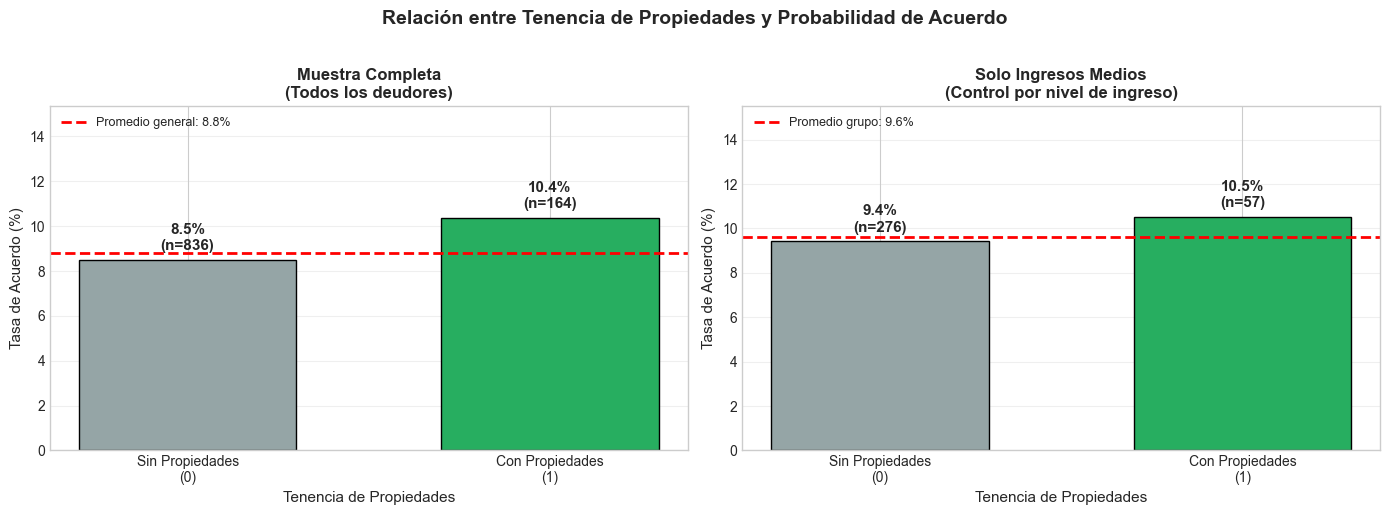


INTERPRETACIÓN

MUESTRA COMPLETA:
  ✓ Deudores CON propiedades tienen 1.9 pp MÁS de tasa de acuerdo

CONTROLANDO POR INGRESO (solo medios):
  ✓ Deudores CON propiedades tienen 1.1 pp MÁS de tasa de acuerdo

ANÁLISIS:
  → El efecto de tener propiedades es similar en la muestra completa
    y controlando por ingreso. Sugiere que la asociación es robusta.


In [22]:
# 1. Calcular tasa de acuerdo por tenencia de propiedades (muestra completa)
tasa_por_propiedad = df.groupby('tiene_propiedades')['acuerdo_logrado'].agg(['mean', 'sum', 'count'])
tasa_por_propiedad.columns = ['Tasa Acuerdo', 'Total Acuerdos', 'N']
tasa_por_propiedad['Tasa Acuerdo (%)'] = tasa_por_propiedad['Tasa Acuerdo'] * 100

print("="*60)
print("TASA DE ACUERDO POR TENENCIA DE PROPIEDADES (MUESTRA COMPLETA)")
print("="*60)
print(f"\nSIN propiedades (0):")
print(f"  Observaciones: {tasa_por_propiedad.loc[0, 'N']}")
print(f"  Acuerdos logrados: {tasa_por_propiedad.loc[0, 'Total Acuerdos']:.0f}")
print(f"  Tasa de acuerdo: {tasa_por_propiedad.loc[0, 'Tasa Acuerdo (%)']:.1f}%")

print(f"\nCON propiedades (1):")
print(f"  Observaciones: {tasa_por_propiedad.loc[1, 'N']}")
print(f"  Acuerdos logrados: {tasa_por_propiedad.loc[1, 'Total Acuerdos']:.0f}")
print(f"  Tasa de acuerdo: {tasa_por_propiedad.loc[1, 'Tasa Acuerdo (%)']:.1f}%")

# 2. Filtrar solo deudores con ingresos medios para control
df_medios = df[df['grupo_ingreso'] == 'Medio'].copy()
tasa_medios = df_medios.groupby('tiene_propiedades')['acuerdo_logrado'].agg(['mean', 'count'])
tasa_medios['mean'] = tasa_medios['mean'] * 100
tasa_medios.columns = ['Tasa Acuerdo (%)', 'N']

print("\n" + "="*60)
print("TASA DE ACUERDO POR PROPIEDADES (SOLO INGRESOS MEDIOS)")
print("="*60)
print(tasa_medios.to_string())

# 3. Crear gráfico comparativo (2 paneles)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Muestra completa
ax1 = axes[0]
categorias = ['Sin Propiedades\n(0)', 'Con Propiedades\n(1)']
tasas_completa = [tasa_por_propiedad.loc[0, 'Tasa Acuerdo (%)'], 
                  tasa_por_propiedad.loc[1, 'Tasa Acuerdo (%)']]
n_completa = [tasa_por_propiedad.loc[0, 'N'], tasa_por_propiedad.loc[1, 'N']]
colores = ['#95A5A6', '#27AE60']

barras1 = ax1.bar(categorias, tasas_completa, color=colores, edgecolor='black', width=0.6)

for barra, tasa, n in zip(barras1, tasas_completa, n_completa):
    ax1.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
             f'{tasa:.1f}%\n(n={n:.0f})', ha='center', va='bottom', 
             fontsize=11, fontweight='bold')

promedio_general = df['acuerdo_logrado'].mean() * 100
ax1.axhline(y=promedio_general, color='red', linestyle='--', linewidth=2,
            label=f'Promedio general: {promedio_general:.1f}%')

ax1.set_xlabel('Tenencia de Propiedades', fontsize=11)
ax1.set_ylabel('Tasa de Acuerdo (%)', fontsize=11)
ax1.set_title('Muestra Completa\n(Todos los deudores)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_ylim(0, max(tasas_completa) + 5)
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: Solo ingresos medios
ax2 = axes[1]
tasas_medios = [tasa_medios.loc[0, 'Tasa Acuerdo (%)'], tasa_medios.loc[1, 'Tasa Acuerdo (%)']]
n_medios = [tasa_medios.loc[0, 'N'], tasa_medios.loc[1, 'N']]

barras2 = ax2.bar(categorias, tasas_medios, color=colores, edgecolor='black', width=0.6)

for barra, tasa, n in zip(barras2, tasas_medios, n_medios):
    ax2.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
             f'{tasa:.1f}%\n(n={n:.0f})', ha='center', va='bottom', 
             fontsize=11, fontweight='bold')

promedio_medios = df_medios['acuerdo_logrado'].mean() * 100
ax2.axhline(y=promedio_medios, color='red', linestyle='--', linewidth=2,
            label=f'Promedio grupo: {promedio_medios:.1f}%')

ax2.set_xlabel('Tenencia de Propiedades', fontsize=11)
ax2.set_ylabel('Tasa de Acuerdo (%)', fontsize=11)
ax2.set_title('Solo Ingresos Medios\n(Control por nivel de ingreso)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.set_ylim(0, max(max(tasas_medios), max(tasas_completa)) + 5)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Relación entre Tenencia de Propiedades y Probabilidad de Acuerdo', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4. Interpretación
print("\n" + "="*60)
print("INTERPRETACIÓN")
print("="*60)

dif_completa = tasas_completa[1] - tasas_completa[0]
dif_medios = tasas_medios[1] - tasas_medios[0]

print("\nMUESTRA COMPLETA:")
if dif_completa > 0:
    print(f"  ✓ Deudores CON propiedades tienen {dif_completa:.1f} pp MÁS de tasa de acuerdo")
else:
    print(f"  ✗ Deudores CON propiedades tienen {abs(dif_completa):.1f} pp MENOS de tasa de acuerdo")

print("\nCONTROLANDO POR INGRESO (solo medios):")
if dif_medios > 0:
    print(f"  ✓ Deudores CON propiedades tienen {dif_medios:.1f} pp MÁS de tasa de acuerdo")
else:
    print(f"  ✗ Deudores CON propiedades tienen {abs(dif_medios):.1f} pp MENOS de tasa de acuerdo")

# Comparar efecto
print("\nANÁLISIS:")
if abs(dif_completa - dif_medios) < 2:
    print("  → El efecto de tener propiedades es similar en la muestra completa")
    print("    y controlando por ingreso. Sugiere que la asociación es robusta.")
else:
    print("  → El efecto cambia al controlar por ingreso.")
    print("    Sugiere que parte del efecto observado podría deberse al ingreso.")

## 3.8 Control de Placebo: Helado Favorito vs Probabilidad de Acuerdo

**Objetivo:** Verificar que no estamos sobreinterpretando patrones aleatorios en los datos.

**Lógica:** La variable `helado_favorito` no tiene ningún mecanismo teórico plausible que la relacione con la probabilidad de llegar a un acuerdo de pago. Si encontramos diferencias estadísticamente significativas aquí, sería evidencia de que:
1. Estamos viendo ruido aleatorio
2. Hay confusores no observados
3. Debemos ser cautelosos con las interpretaciones causales de otros análisis

*Este es un test de sanidad/placebo para el análisis exploratorio.*

Plot Twist Técnico (Estrategia que experimenté en esta ocación)

TASA DE ACUERDO POR HELADO FAVORITO

(Ordenado por tasa de acuerdo)

  fresa: 10.6% (21/199)
  otro: 10.2% (20/196)
  chocolate: 9.5% (19/199)
  ron con pasas: 8.5% (17/199)
  No le gusta el helado: 5.3% (11/207)


C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\4069799212.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_por_helado = df.groupby('helado_favorito')['acuerdo_logrado'].agg(['mean', 'sum', 'count'])
C:\Users\Juan D Anzola Q\AppData\Local\Temp\ipykernel_3244\4069799212.py:58: UserWarning: Glyph 127846 (\N{SOFT ICE CREAM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Juan D Anzola Q\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127846 (\N{SOFT ICE CREAM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


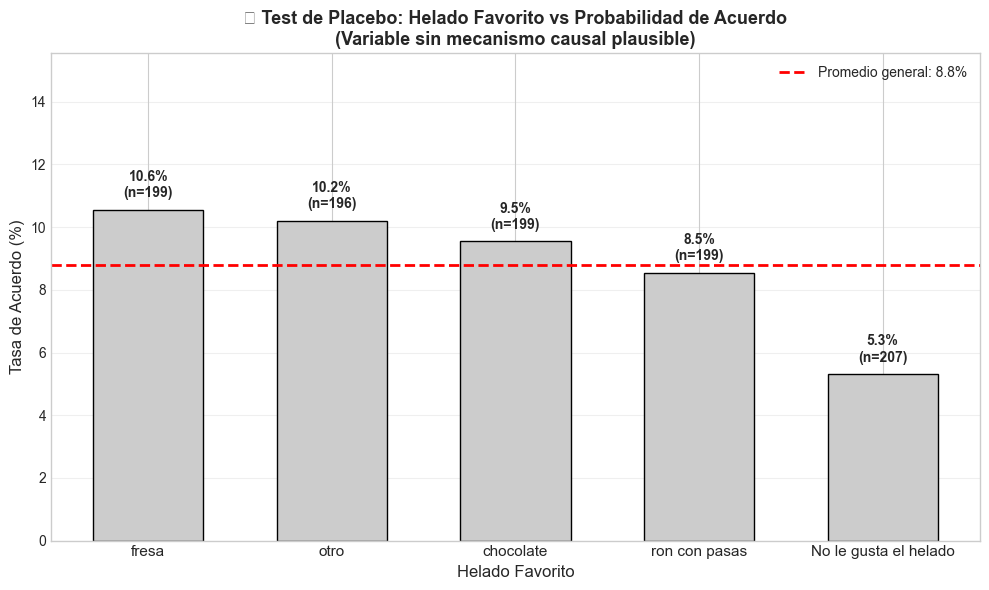


ANÁLISIS DE VARIABILIDAD

Tasa máxima: 10.6% (fresa)
Tasa mínima: 5.3% (No le gusta el helado)
Rango: 5.2 puntos porcentuales
Desviación estándar: 2.11


In [23]:
# 1. Calcular tasa de acuerdo por categoría de helado favorito
tasa_por_helado = df.groupby('helado_favorito')['acuerdo_logrado'].agg(['mean', 'sum', 'count'])
tasa_por_helado.columns = ['Tasa Acuerdo', 'Total Acuerdos', 'N']
tasa_por_helado['Tasa Acuerdo (%)'] = tasa_por_helado['Tasa Acuerdo'] * 100
tasa_por_helado = tasa_por_helado.sort_values('Tasa Acuerdo (%)', ascending=False)

print("="*60)
print("TASA DE ACUERDO POR HELADO FAVORITO")
print("="*60)
print("\n(Ordenado por tasa de acuerdo)\n")
for helado in tasa_por_helado.index:
    tasa = tasa_por_helado.loc[helado, 'Tasa Acuerdo (%)']
    n = tasa_por_helado.loc[helado, 'N']
    acuerdos = tasa_por_helado.loc[helado, 'Total Acuerdos']
    print(f"  {helado}: {tasa:.1f}% ({acuerdos:.0f}/{n:.0f})")

# 2. Crear gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))

# Usar colores de helado para las barras (solo decorativo)
colores_helado = {
    'Chocolate': '#8B4513',
    'Vainilla': '#F5DEB3',
    'Fresa': '#FF69B4',
    'Menta': '#98FB98',
    'Limón': '#FFFACD'
}

# Obtener colores en orden
categorias = tasa_por_helado.index.tolist()
tasas = tasa_por_helado['Tasa Acuerdo (%)'].values
ns = tasa_por_helado['N'].values
colores = [colores_helado.get(cat, '#CCCCCC') for cat in categorias]

barras = ax.bar(range(len(categorias)), tasas, color=colores, edgecolor='black', width=0.6)

# Etiquetas sobre las barras
for i, (barra, tasa, n) in enumerate(zip(barras, tasas, ns)):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
            f'{tasa:.1f}%\n(n={n:.0f})', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

# Línea de promedio general
promedio_general = df['acuerdo_logrado'].mean() * 100
ax.axhline(y=promedio_general, color='red', linestyle='--', linewidth=2,
           label=f'Promedio general: {promedio_general:.1f}%')

ax.set_xticks(range(len(categorias)))
ax.set_xticklabels(categorias, fontsize=11)
ax.set_xlabel('Helado Favorito', fontsize=12)
ax.set_ylabel('Tasa de Acuerdo (%)', fontsize=12)
ax.set_title('🍦 Test de Placebo: Helado Favorito vs Probabilidad de Acuerdo\n(Variable sin mecanismo causal plausible)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, max(tasas) + 5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 3. Análisis estadístico simple
print("\n" + "="*60)
print("ANÁLISIS DE VARIABILIDAD")
print("="*60)

max_tasa = tasa_por_helado['Tasa Acuerdo (%)'].max()
min_tasa = tasa_por_helado['Tasa Acuerdo (%)'].min()
rango = max_tasa - min_tasa
desv_std = tasa_por_helado['Tasa Acuerdo (%)'].std()

print(f"\nTasa máxima: {max_tasa:.1f}% ({tasa_por_helado['Tasa Acuerdo (%)'].idxmax()})")
print(f"Tasa mínima: {min_tasa:.1f}% ({tasa_por_helado['Tasa Acuerdo (%)'].idxmin()})")
print(f"Rango: {rango:.1f} puntos porcentuales")
print(f"Desviación estándar: {desv_std:.2f}")
